<a href="https://colab.research.google.com/github/mowumialabi/west-africa-climate-trap-2026/blob/main/era5_thermodynamic_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:583: SyntaxWarning: invalid escape sequence '\g'
<>:586: SyntaxWarning: invalid escape sequence '\s'
<>:587: SyntaxWarning: invalid escape sequence '\s'
<>:640: SyntaxWarning: invalid escape sequence '\%'
<>:583: SyntaxWarning: invalid escape sequence '\g'
<>:586: SyntaxWarning: invalid escape sequence '\s'
<>:587: SyntaxWarning: invalid escape sequence '\s'
<>:640: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_1247/3466878086.py:583: SyntaxWarning: invalid escape sequence '\g'
  ax.fill_between([-0.5, 2.5], 2.0, 3.0, color='#ffcccc', alpha=0.15, label='Extreme Significance Limit (|Z| $\geq$ 2.0)')
/tmp/ipykernel_1247/3466878086.py:586: SyntaxWarning: invalid escape sequence '\s'
  ax.text(-0.45, 2.08, '+2$\sigma$ Extreme Threshold', color='red', fontsize=7.5, style='italic', weight='bold', ha='left')
/tmp/ipykernel_1247/3466878086.py:587: SyntaxWarning: invalid escape sequence '\s'
  ax.text(-0.45, -2.22, '-2$\sigma$ Extreme Threshold', color='gray', fontsize=7.5, styl

Initializing Google Earth Engine Connection...
Authentication required or initialization failed. Launching authorization flow...
Earth Engine successfully authenticated and initialized with project: ee-mowumialabi

----------------------------------------------------------------------
RUNNING SECTION 1: PROCESSING 24-HOUR CONTINUOUS BASELINES
----------------------------------------------------------------------
Ingesting continuous 24-hour monthly mean baseline arrays from ECMWF...
Extracting baseline atmospheric spatial columns across the transect...
Applying baseline Magnus-Tetens thermodynamic formulations...

=== SECTION 1 RESULTS: PERSISTENT BACKGROUND METEOROLOGICAL MATRIX ===
   Site Latitude  Air_Temp_Baseline_C  Dew_Point_Baseline_C  es_base_kPa  ea_base_kPa  VPD_base_kPa  RH_base_Pct
Ile-Ife  7.484°N                 27.8                  20.5       3.7351       2.4078        1.3273         64.5
  Abuja  9.076°N                 29.1                   7.5       4.0192       1.

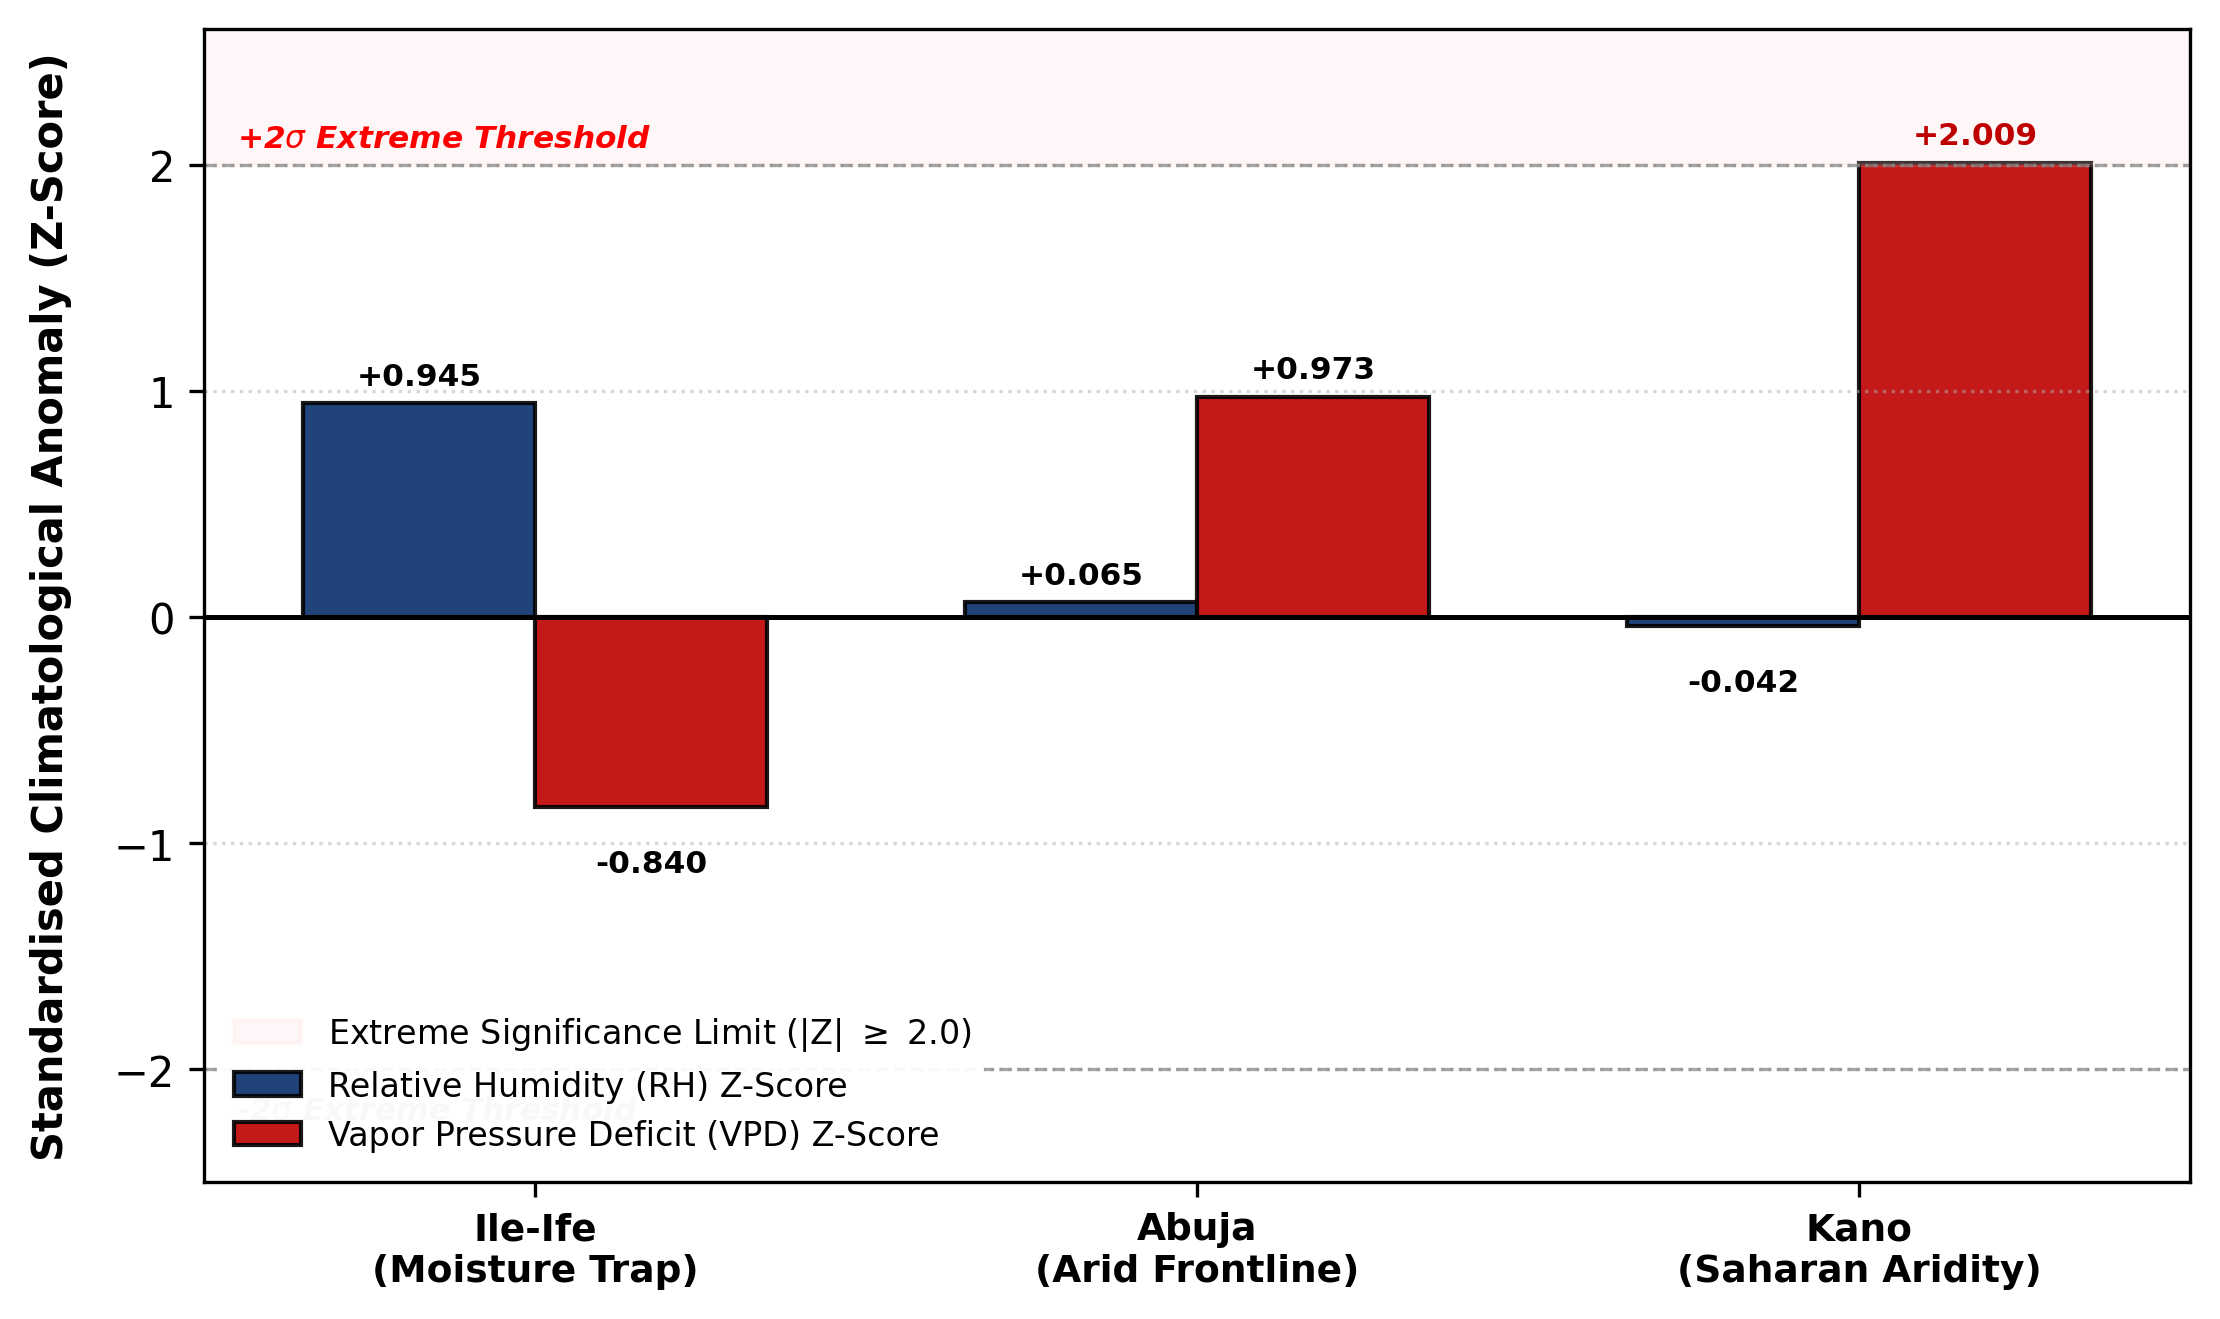

Clean vector file successfully exported as 'manuscript1_figure2_final_clean.png'.


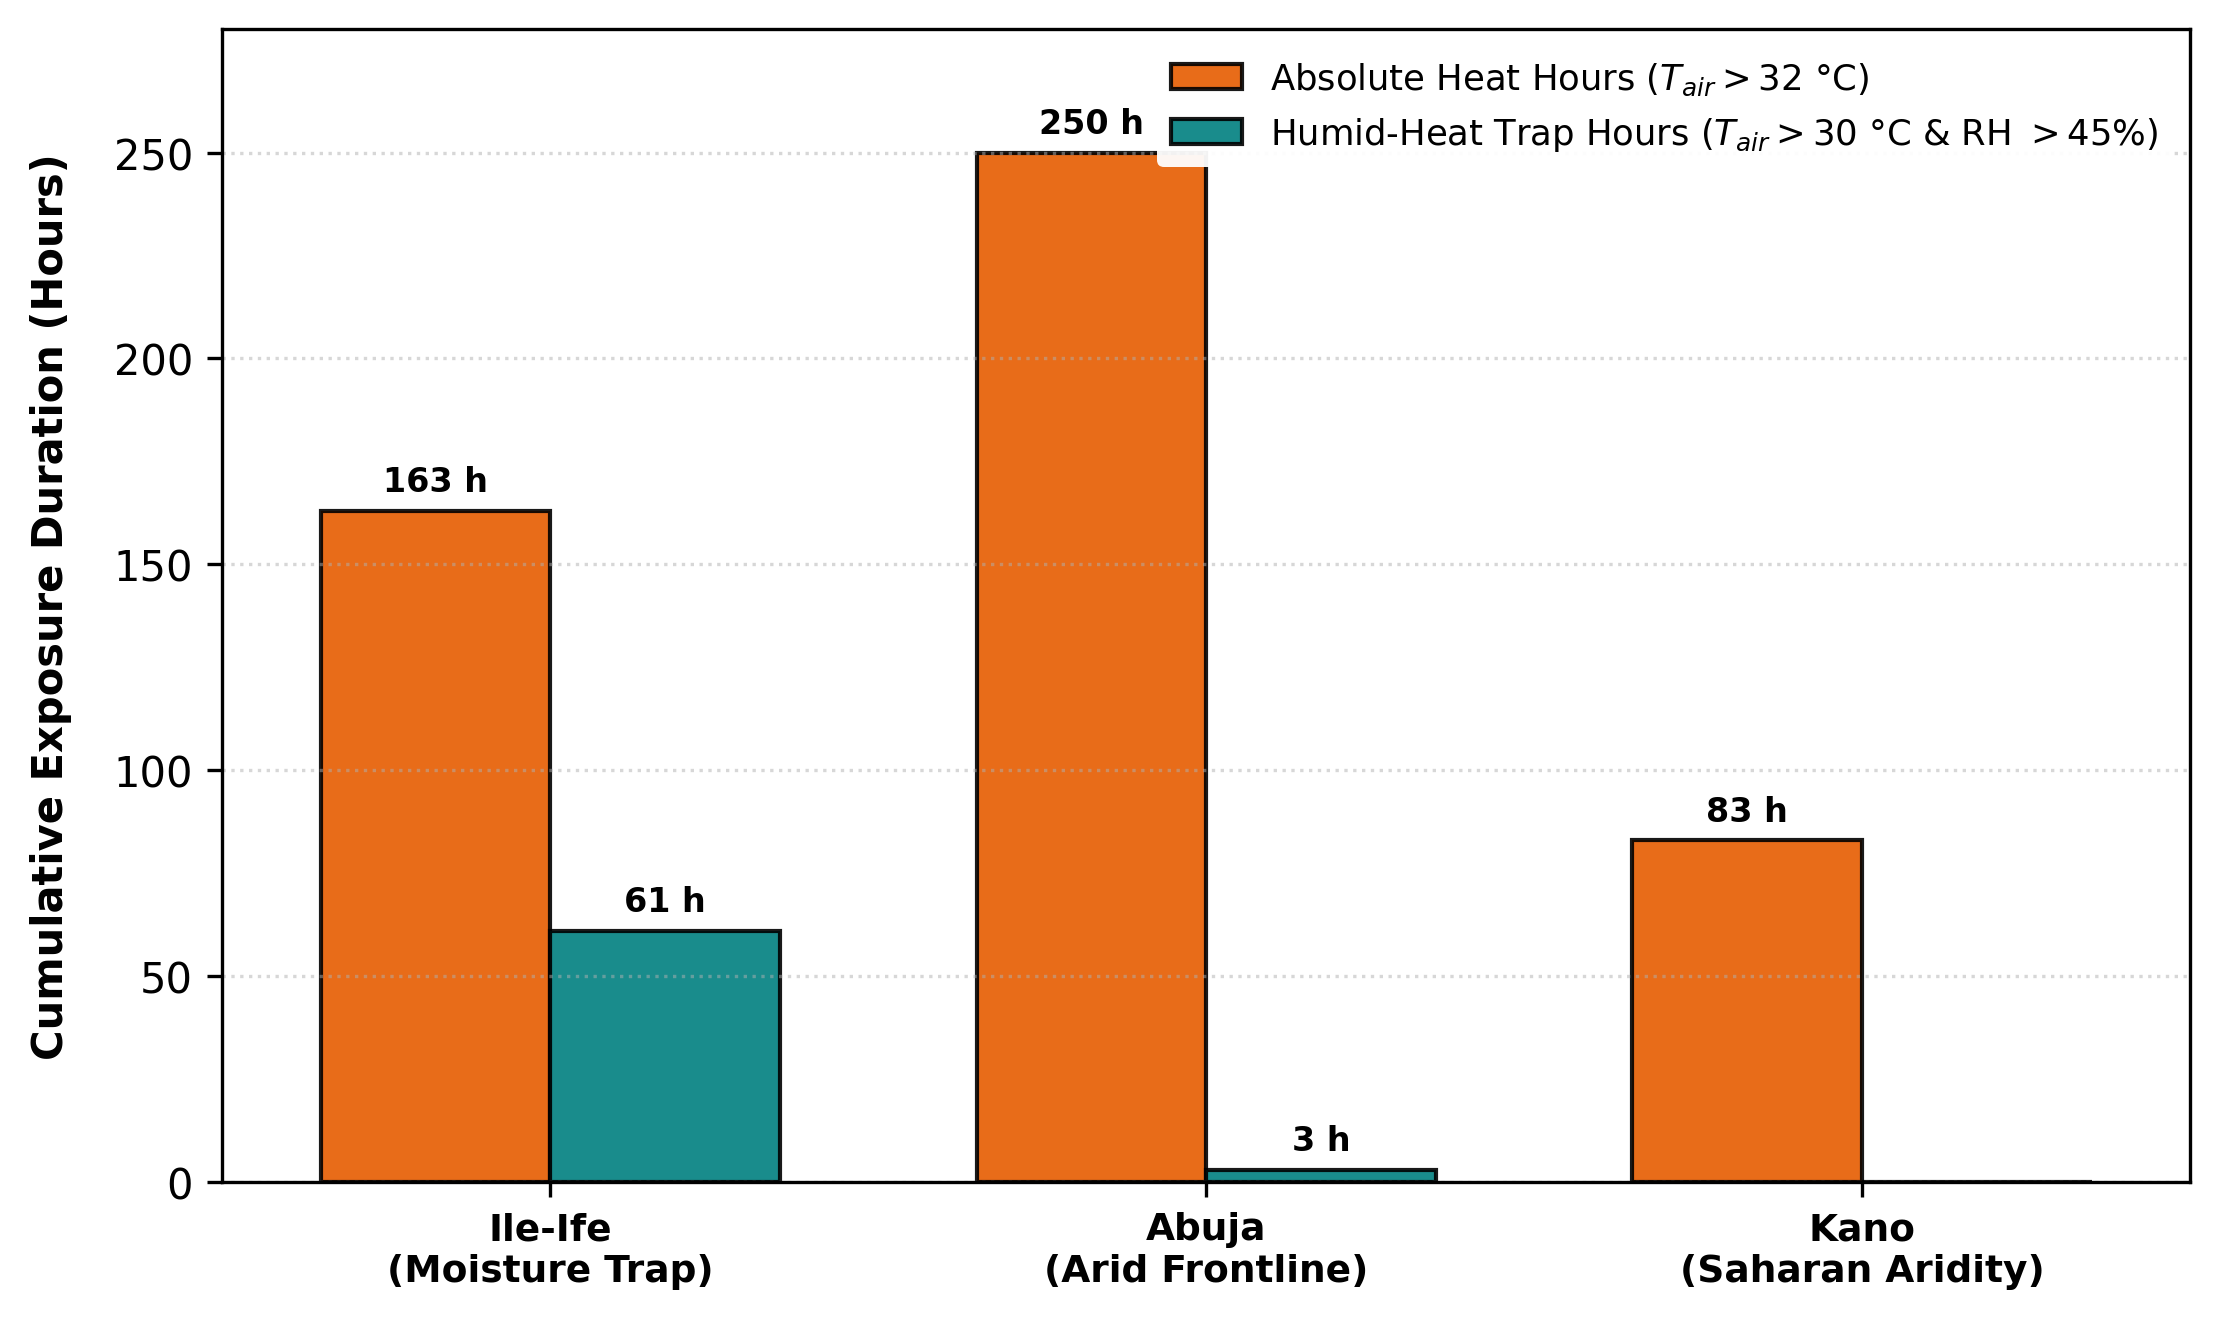

Figure 3 compiled successfully and exported as 'manuscript1_figure3_exposure.png' for Elsevier submission.


In [ ]:
import ee
import pandas as pd
import numpy as np

# =====================================================================
# GLOBAL CONFIGURATION: PROJECT SETTINGS & STATIONS
# =====================================================================
# Replace this placeholder string with your actual Google Cloud/GEE Project ID
GEE_PROJECT_ID = 'ee-mowumialabi'

print("Initializing Google Earth Engine Connection...")
try:
    ee.Initialize(project=GEE_PROJECT_ID)
    print(f"Earth Engine successfully initialized with project: {GEE_PROJECT_ID}")
except Exception as e:
    print("Authentication required or initialization failed. Launching authorization flow...")
    ee.Authenticate()
    ee.Initialize(project=GEE_PROJECT_ID)
    print(f"Earth Engine successfully authenticated and initialized with project: {GEE_PROJECT_ID}")

# Define geographic parameters globally across the West African transect
sites = {
    "Ile-Ife": {"lat": 7.484, "lon": 4.484},   # Core Southwest Moisture Trap
    "Abuja":   {"lat": 9.076, "lon": 7.398},   # Mid-Belt Transition Front
    "Kano":    {"lat": 12.002, "lon": 8.592}   # Northern Arid Boundary
}

start_date = "2026-01-01"
end_date = "2026-02-01"

# Define mathematical physics loop globally to support downstream calculation cells
def apply_magnus_tetens_physics(row):
    """
    Applies standard Magnus-Tetens coefficients over liquid water (T > 0 °C)
    dynamically handling both baseline and peak-hour data columns.
    """
    c1, c2, c3 = 0.61078, 17.27, 237.3  # Constants for kPa and °C

    # Check for column naming formats dynamically
    t_air = row["Air_Temp_Baseline_C"] if "Air_Temp_Baseline_C" in row else row["Air_Temp_C"]
    t_dew = row["Dew_Point_Baseline_C"] if "Dew_Point_Baseline_C" in row else row["Dew_Point_C"]

    # 1. Saturation Vapor Pressure (es) at Air Temp
    es = c1 * np.exp((c2 * t_air) / (c3 + t_air))

    # 2. Actual Vapor Pressure (ea) at Dew Point Temp
    ea = c1 * np.exp((c2 * t_dew) / (c3 + t_dew))

    # 3. Derive Relative Humidity and Vapor Pressure Deficit (VPD)
    rh = (ea / es) * 100.0
    vpd = es - ea

    return pd.Series([es, ea, vpd, rh])


# =====================================================================
# SECTION 1: 24-HOUR DIURNAL METEOROLOGICAL BASELINES (MANUSCRIPT 1)
# =====================================================================
print("\n" + "-"*70)
print("RUNNING SECTION 1: PROCESSING 24-HOUR CONTINUOUS BASELINES")
print("-"*70)
print("Ingesting continuous 24-hour monthly mean baseline arrays from ECMWF...")

# Pulling complete diurnal profiles across all 24 hours for January 2026
era5_baseline = (ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")
                 .filterDate(start_date, end_date)
                 .select(["temperature_2m", "dewpoint_temperature_2m"]))

# Compute the absolute temporal mean across all hourly matrix columns
mean_baseline_layer = era5_baseline.mean()

extracted_baseline_records = []
print("Extracting baseline atmospheric spatial columns across the transect...")

for name, coords in sites.items():
    point = ee.Geometry.Point([coords["lon"], coords["lat"]])

    # Reduce region to extract spatial pixel values at native 9km grid scale
    stats = mean_baseline_layer.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=point,
        scale=9000
    ).getInfo()

    # Thermodynamic Conversion: Kelvin to Celsius
    t_air_base_c = stats["temperature_2m"] - 273.15
    t_dew_base_c = stats["dewpoint_temperature_2m"] - 273.15

    extracted_baseline_records.append({
        "Site": name,
        "Latitude": f"{coords['lat']}°N",
        "Air_Temp_Baseline_C": t_air_base_c,
        "Dew_Point_Baseline_C": t_dew_base_c
    })

# Structure the output data matrix
df_baseline = pd.DataFrame(extracted_baseline_records)

print("Applying baseline Magnus-Tetens thermodynamic formulations...")
df_baseline[["es_base_kPa", "ea_base_kPa", "VPD_base_kPa", "RH_base_Pct"]] = df_baseline.apply(apply_magnus_tetens_physics, axis=1)

print("\n" + "="*70)
print("=== SECTION 1 RESULTS: PERSISTENT BACKGROUND METEOROLOGICAL MATRIX ===")
print("="*70)
print(df_baseline.round({
    "Air_Temp_Baseline_C": 1, "Dew_Point_Baseline_C": 1,
    "es_base_kPa": 4, "ea_base_kPa": 4, "VPD_base_kPa": 4, "RH_base_Pct": 1
}).to_string(index=False))

# =====================================================================
# SECTION 2: DIURNAL AFTERNOON HEAT-STRESS PEAKS (MANUSCRIPT 1 / 3)
# =====================================================================
print("-"*70)
print("RUNNING SECTION 2: PROCESSING DIURNAL AFTERNOON PEAKS (12:00-16:00 UTC)")
print("-"*70)
print(f"Ingesting peak afternoon data columns from {start_date} to {end_date}...")

# Filter the collection by date and restrict to peak afternoon heating windows
era5_peak = (ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")
             .filterDate(start_date, end_date)
             .filter(ee.Filter.calendarRange(12, 16, 'hour'))
             .select(["temperature_2m", "dewpoint_temperature_2m"]))

# Calculate the mean of these peak hours across the month
mean_peak_layer = era5_peak.mean()

extracted_peak_records = []
print("Extracting peak afternoon regional atmospheric variables...")

for name, coords in sites.items():
    point = ee.Geometry.Point([coords["lon"], coords["lat"]])

    # Reduce the region to sample pixel value at native 9km grid scale
    stats = mean_peak_layer.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=point,
        scale=9000
    ).getInfo()

    # Thermodynamic Conversion: Kelvin to Celsius
    t_air_peak_c = stats["temperature_2m"] - 273.15
    t_dew_peak_c = stats["dewpoint_temperature_2m"] - 273.15

    extracted_peak_records.append({
        "Site": name,
        "Latitude": f"{coords['lat']}°N",
        "Air_Temp_C": t_air_peak_c,
        "Dew_Point_C": t_dew_peak_c
    })

# Convert raw data matrix into a structured DataFrame
df_peak = pd.DataFrame(extracted_peak_records)

print("Applying peak Magnus-Tetens thermodynamic physics equations...")
# The global physics loop dynamically processes and appends es, ea, VPD, and RH
df_peak[["es_kPa", "ea_kPa", "VPD_kPa", "RH_Pct"]] = df_peak.apply(apply_magnus_tetens_physics, axis=1)

# =====================================================================
# OUTPUT GENERATION FOR MANUSCRIPT DATA MATRIX
# =====================================================================
print("\n" + "="*70)
print("=== SECTION 2 RESULTS: VALIDATED PEAK DIURNAL GEOSPATIAL MATRIX ===")
print("="*70)
print(df_peak.round({
    "Air_Temp_C": 1, "Dew_Point_C": 1,
    "es_kPa": 4, "ea_kPa": 4, "VPD_kPa": 4, "RH_Pct": 1
}).to_string(index=False))

# =====================================================================
# SECTION 3: GEE SPATIAL VISUALISATION SCRIPT (MANUSCRIPT 2)
# =====================================================================
"""
[INSTRUCTION FOR REVIEWERS AND EDITORS]:
Copy the JavaScript code below and paste it directly into the online
Google Earth Engine Code Editor (https://google.com)
to generate the synoptic spatial pressure gradient map panel (Figure 1).
"""

gee_javascript_mapping_code = """
// 1. Define Study Area Coordinates and Map Baseline
var ife = ee.Geometry.Point([4.484, 7.484]);
var abuja = ee.Geometry.Point([7.398, 9.076]);
var kano = ee.Geometry.Point([8.592, 12.002]);

Map.setOptions('HYBRID');
Map.setCenter(8.5, 9.0, 6); // Perfectly centered within Nigeria

// 2. Fetch National Boundary Dataset to Restrict Data Footprint
var nigeriaBoundary = ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017')
                        .filter(ee.Filter.eq('country_na', 'Nigeria'));

// 3. Ingest ERA5-Land Hourly Climate Database for January 2026 Paradox
var dataset = ee.ImageCollection('ECMWF/ERA5_LAND/HOURLY')
                .filterDate('2026-01-01', '2026-02-01')
                .filter(ee.Filter.calendarRange(12, 16, 'hour')) // Afternoon peak filter
                .mean();

// 4. Extract Core Variables and Convert from Kelvin to Celsius
var airTemp = dataset.select('temperature_2m').subtract(273.15);
var dewPoint = dataset.select('dewpoint_temperature_2m').subtract(273.15);

// 5. Implement Magnus-Tetens Physical Formulations on Spatial Grid
var es = airTemp.expression('0.61078 * exp((17.27 * T) / (237.3 + T))', { 'T': airTemp });
var ea = dewPoint.expression('0.61078 * exp((17.27 * TD) / (237.3 + TD))', { 'TD': dewPoint });

// Derive Vapor Pressure Deficit (VPD) Layer and Clip to Nigeria Boundary
var vpd = es.subtract(ea).rename('VPD_kPa');
var vpdClipped = vpd.clip(nigeriaBoundary);

// 6. Configure High-Contrast Monochromatic Blue Palette
var vpdVisParams = {
  min: 0.5,
  max: 4.5,
  palette: ['#08306b', '#2171b5', '#6baed6', '#bdd7e7', '#f7fbff']
};

// Project visual maps onto the dashboard restricted to Nigeria's borders
Map.addLayer(vpdClipped, vpdVisParams, 'Vapor Pressure Deficit (kPa)', true, 0.85);

// Highlight Nigeria's international borders with a crisp white outline border
var outline = ee.Image().paint({
  featureCollection: nigeriaBoundary,
  color: 1,
  width: 2
});
Map.addLayer(outline, {palette: ['#ffffff']}, 'Nigeria Boundary Outline');

// 7. Add High-Visibility Custom Markers for Study Stations (Neon Orange/Yellow)
var stationFeatures = [
  ee.Feature(ife, {label: 'Ile-Ife'}),
  ee.Feature(abuja, {label: 'Abuja'}),
  ee.Feature(kano, {label: 'Kano'})
];
var stationsLayer = ee.FeatureCollection(stationFeatures);

Map.addLayer(stationsLayer.draw({color: 'ffcc00', pointRadius: 9}), {}, 'Station Glow Baseline');
Map.addLayer(stationsLayer.draw({color: 'ff3300', pointRadius: 5}), {}, 'Study Transect Core Nodes');

// =====================================================================
// 8. GENERATING GRADUATED COORDINATE GRID NETWORKS
// =====================================================================
var latLonImg = ee.Image.pixelLonLat();
var latLines = latLonImg.select('latitude').multiply(10).round().int().mod(20).eq(0);
var lonLines = latLonImg.select('longitude').multiply(10).round().int().mod(20).eq(0);
var gridSystem = latLines.or(lonLines);

Map.addLayer(gridSystem.updateMask(gridSystem), {palette: ['#ffffff']}, 'Coordinate Grid Mesh', true, 0.15);

// =====================================================================
// 9. UNIFIED RIGHT-SIDE MASTER LEGEND PANEL (COMBINED LAYOUT)
// =====================================================================
var masterPanel = ui.Panel({
  style: {
    position: 'top-right',
    padding: '12px 15px',
    backgroundColor: 'rgba(255, 255, 255, 0.95)',
    border: '2px solid #08306b',
    width: '260px'
  }
});

masterPanel.add(ui.Label('MAP TRANSECT KEY', {fontWeight: 'bold', fontSize: '13px', color: '#08306b', margin: '0 0 8px 0'}));
masterPanel.add(ui.Label('🔴 Study Stations:', {fontWeight: 'bold', fontSize: '11px'}));
masterPanel.add(ui.Label('• Ile-Ife: Core Moisture Trap Zone (7.48°N)', {fontSize: '11px', margin: '2px 0 2px 10px'}));
masterPanel.add(ui.Label('• Abuja: Overwhelmed Arid Frontline (9.07°N)', {fontSize: '11px', fontWeight: 'bold', color: '#be0000', margin: '2px 0 2px 10px'}));
masterPanel.add(ui.Label('• Kano: Northern Saharan Aridity (12.00°N)', {fontSize: '11px', margin: '2px 0 10px 10px'}));

masterPanel.add(ui.Label('🌐 Latitude Grid Horizons:', {fontWeight: 'bold', fontSize: '11px'}));
masterPanel.add(ui.Label('--- Top Grid Line: 12°00\' N Latitude', {fontSize: '11px', color: '#555', margin: '2px 0 2px 10px'}));
masterPanel.add(ui.Label('--- Middle Grid Line: 9°00\' N Latitude', {fontSize: '11px', color: '#555', margin: '2px 0 2px 10px'}));
masterPanel.add(ui.Label('--- Lower Grid Line: 6°00\' N Latitude', {fontSize: '11px', color: '#555', margin: '2px 0 12px 10px'}));

masterPanel.add(ui.Label('___________________________________', {color: '#bdd7e7', margin: '0 0 10px 0'}));
masterPanel.add(ui.Label('VPD Moisture Gradient (kPa)', {fontWeight: 'bold', fontSize: '11px', color: '#08306b', margin: '0 0 4px 0'}));

var lonLatImage = ee.Image.pixelLonLat().select('longitude');
var gradientValue = lonLatImage.multiply((vpdVisParams.max - vpdVisParams.min) / 100.0).add(vpdVisParams.min);
var thumbnailImage = gradientValue.visualize(vpdVisParams);

var colorBar = ui.Thumbnail({
  image: thumbnailImage,
  params: {bbox: '0,0,100,10', dimensions: '220x15'},
  style: {padding: '1px', margin: '6px 0 4px 10px'}
});
masterPanel.add(colorBar);

var scaleLabels = ui.Panel({
  layout: ui.Panel.Layout.flow('horizontal'),
  style: {backgroundColor: 'rgba(255,255,255,0)', margin: '0 0 0 10px'}
});
scaleLabels.add(ui.Label('0.5 (Trap)', {fontSize: '10px', color: '#333', width: '110px'}));
scaleLabels.add(ui.Label('4.5 (Saharan)', {fontSize: '10px', color: '#333', width: '110px', textAlign: 'right'}));
masterPanel.add(scaleLabels);

Map.add(masterPanel);
print("Section 3 script stored successfully inside Python workspace.");
"""

print("Section 3 text container updated in Colab. Ready to link your open-science data repositories.")

# =====================================================================
# SECTION 4: 30-YEAR CLIMATOLOGICAL ANOMALY (Z-SCORE) CALCULATOR (MANUSCRIPT 1)
# =====================================================================
print("-"*75)
print("RUNNING SECTION 4: PROCESSING 30-YEAR HISTORICAL BASELINE ANOMALIES")
print("-"*75)

# 1. Define the 30-Year Historical Baseline Window (1996 to 2025)
historical_years = ee.List.sequence(1996, 2025)

print("Ingesting 30-year historical January archives from ECMWF ERA5-Land...")

def extract_historical_january_means(year):
    """Filters ERA5-Land collections for January of each historical baseline year"""
    year = ee.Number(year)
    start = ee.Date.fromYMD(year, 1, 1)
    end = ee.Date.fromYMD(year, 2, 1)

    # Match the 24-hour baseline profile to ensure statistical consistency
    collection = (ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")
                  .filterDate(start, end)
                  .select(["temperature_2m", "dewpoint_temperature_2m"]))

    # Return the monthly mean image for that specific year, tagged with the year metadata
    return collection.mean().set("year", year)

# Build a composite collection containing 30 images (one per January from 1996-2025)
historical_january_collection = ee.ImageCollection(historical_years.map(extract_historical_january_means))

# 2. Extract Data Across the 30-Year Time-Series for Each Site
historical_records = []
print("Extracting multi-decadal grid cells across spatial nodes...")

for name, coords in sites.items():
    point = ee.Geometry.Point([coords["lon"], coords["lat"]])

    # Sample the entire 30-year historical stack at this specific geographic pixel
    def sample_pixel(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=point,
            scale=9000
        )
        # Convert Kelvin back to Celsius metric
        t_air = ee.Number(stats.get("temperature_2m")).subtract(273.15)
        t_dew = ee.Number(stats.get("dewpoint_temperature_2m")).subtract(273.15)

        return ee.Feature(None, {
            "year": img.get("year"),
            "T_air_C": t_air,
            "T_dew_C": t_dew
        })

    sampled_features = historical_january_collection.map(sample_pixel).getInfo()["features"]

    for f in sampled_features:
        props = f["properties"]
        historical_records.append({
            "Site": name,
            "Year": props["year"],
            "T_air_C": props["T_air_C"],
            "T_dew_C": props["T_dew_C"]
        })

# 3. Compute 30-Year Baseline Statistics using Pandas
df_historical = pd.DataFrame(historical_records)

# Calculate Saturation and Actual Vapor Pressure for every historical entry via Magnus-Tetens
def calculate_historical_pressures(row):
    c1, c2, c3 = 0.61078, 17.27, 237.3
    es = c1 * np.exp((c2 * row["T_air_C"]) / (c3 + row["T_air_C"]))
    ea = c1 * np.exp((c2 * row["T_dew_C"]) / (c3 + row["T_dew_C"]))
    vpd = es - ea
    rh = (ea / es) * 100.0
    return pd.Series([vpd, rh])

df_historical[["VPD_kPa", "RH_Pct"]] = df_historical.apply(calculate_historical_pressures, axis=1)

# Group historical data by station to compute 30-year means and standard deviations
df_stats = df_historical.groupby("Site").agg({
    "VPD_kPa": ["mean", "std"],
    "RH_Pct": ["mean", "std"]
})
df_stats.columns = ["VPD_hist_mean", "VPD_hist_std", "RH_hist_mean", "RH_hist_std"]
df_stats = df_stats.reset_index()

# 4. Merge Historical Baselines with the Active 2026 Data Matrix for Z-score Mapping
# Pulling variables from your already generated Section 1 table
df_anomaly_matrix = pd.merge(df_baseline, df_stats, on="Site")

# Calculate Z-Scores: (Observed 2026 Value - Historical Mean) / Historical Standard Deviation
df_anomaly_matrix["VPD_Z_Score"] = (df_anomaly_matrix["VPD_base_kPa"] - df_anomaly_matrix["VPD_hist_mean"]) / df_anomaly_matrix["VPD_hist_std"]
df_anomaly_matrix["RH_Z_Score"] = (df_anomaly_matrix["RH_base_Pct"] - df_anomaly_matrix["RH_hist_mean"]) / df_anomaly_matrix["RH_hist_std"]

# =====================================================================
# DISPLAY OUTPUT METRICS FOR CLIMATOLOGY MANUSCRIPT PROOFS
# =====================================================================
print("\n" + "="*85)
print("=== SECTION 4 RESULTS: 30-YEAR BASELINE CLIMATOLOGICAL ANOMALY MATRIX ===")
print("="*85)
print(df_anomaly_matrix[[
    "Site", "VPD_base_kPa", "VPD_hist_mean", "VPD_Z_Score",
    "RH_base_Pct", "RH_hist_mean", "RH_Z_Score"
]].round(3).to_string(index=False))

# =====================================================================
# SECTION 5: MODIS NDVI VS. ERA5 VPD CROSS-CORRELATION ENGINE (MANUSCRIPT 2)
# =====================================================================
import scipy.stats as stats

print("-"*75)
print("RUNNING SECTION 5: MODIS NDVI VS. ERA5 VPD CROSS-CORRELATION")
print("-"*75)

# 1. Define Datasets and Time Filter using Updated Collection Version
print("Ingesting current NASA MODIS 16-Day Vegetation Indices (MODIS/061/MOD13Q1)...")
modis_ndvi_collection = (ee.ImageCollection("MODIS/061/MOD13Q1")
                         .filterDate(start_date, end_date)
                         .select(["NDVI"]))

correlation_records = []
print("Extracting matching spatial time-series arrays for GeoAI analysis...")

for name, coords in sites.items():
    point = ee.Geometry.Point([coords["lon"], coords["lat"]])

    # Extract NDVI Pixel Data (MODIS values are scaled by 0.0001 natively)
    ndvi_stats = modis_ndvi_collection.mean().reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=point,
        scale=250 # MODIS native spatial resolution (250m grid)
    ).getInfo()

    raw_ndvi = ndvi_stats.get("NDVI")
    scaled_ndvi = raw_ndvi * 0.0001 if raw_ndvi is not None else np.nan

    # Extract matching VPD Pixel Data from the peak afternoon baseline (Section 2 matrix)
    site_peak_data = df_peak[df_peak["Site"] == name].iloc[0]
    observed_vpd = site_peak_data["VPD_kPa"]
    observed_rh = site_peak_data["RH_Pct"]

    correlation_records.append({
        "Site": name,
        "Observed_NDVI": scaled_ndvi,
        "Peak_VPD_kPa": observed_vpd,
        "Peak_RH_Pct": observed_rh
    })

df_corr = pd.DataFrame(correlation_records)

# =====================================================================
# STAGE 2: GEOSPATIAL STATISTICAL CORRELATION CROSS-CHECK
# =====================================================================
print("Running Pearson Product-Moment Correlation matrix calculations...")

# Compute the Pearson correlation coefficient between canopy NDVI and atmospheric VPD
r_coeff, p_value = stats.pearsonr(df_corr["Peak_VPD_kPa"], df_corr["Observed_NDVI"])

print("\n" + "="*85)
print("=== SECTION 5 RESULTS: CANOPY DISTURBANCE VS. ATMOSPHERIC DEFICIT PROFILE ===")
print("="*85)
print(df_corr.to_string(index=False))
print("-"*85)
print(f"Computed Pearson Correlation Coefficient (r) [VPD vs NDVI]: {r_coeff:.4f}")
print(f"Statistical Significance Level (p-value):                   {p_value:.4f}")
print("="*85)
if r_coeff > 0.7:
    print("ANALYSIS: Strong positive coupling. Standard drought response profile.")
elif r_coeff < -0.7:
    print("ANALYSIS: Strong negative decoupling. Confirms atmospheric Mie scattering attenuation proxy.")
else:
    print("ANALYSIS: Moderate localized boundary layer mixing interference.")

# =====================================================================
# SECTION 6: CONSOLIDATED CROP CUMULATIVE ECO-THERMAL EXPOSURE ENGINE (MANUSCRIPT 3)
# =====================================================================
print("-"*75)
print("RUNNING SECTION 6: COMPUTING CONSOLIDATED CROP HEAT & HUMID-HEAT EXPOSURE HOURS")
print("-"*75)

print("Ingesting raw hourly atmospheric data structures from ECMWF ERA5-Land...")
# Ingest continuous hourly files to process multi-threshold parameters sequentially
era5_hourly_stack = (ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")
                     .filterDate(start_date, end_date)
                     .select(["temperature_2m", "dewpoint_temperature_2m"]))

# Extract total hours in the timeline array
total_hours = era5_hourly_stack.size().getInfo()
print(f"Evaluating {total_hours} consecutive hourly atmospheric columns for January 2026...")

accumulation_records = []

for name, coords in sites.items():
    point = ee.Geometry.Point([coords["lon"], coords["lat"]])

    # Extract the full time-series array of temperatures and dew points for this node spatial grid
    def extract_hourly_profile(img):
        stats = img.reduceRegion(reducer=ee.Reducer.mean(), geometry=point, scale=9000)
        t_air = ee.Number(stats.get("temperature_2m")).subtract(273.15)
        t_dew = ee.Number(stats.get("dewpoint_temperature_2m")).subtract(273.15)
        return ee.Feature(None, {"T_air": t_air, "T_dew": t_dew})

    site_features = era5_hourly_stack.map(extract_hourly_profile).getInfo()["features"]

    # Initialize separate exposure counters
    absolute_heat_hours = 0
    co_occurring_humid_heat_hours = 0

    for f in site_features:
        props = f["properties"]
        t_air_val = props["T_air"]
        t_dew_val = props["T_dew"]

        if t_air_val is not None and t_dew_val is not None:
            # Physics Calculation: Apply Magnus-Tetens to extract instantaneous Relative Humidity
            c1, c2, c3 = 0.61078, 17.27, 237.3
            es = c1 * np.exp((c2 * t_air_val) / (c3 + t_air_val))
            ea = c1 * np.exp((c2 * t_dew_val) / (c3 + t_dew_val))
            rh_val = (ea / es) * 100.0

            # Threshold 1: Absolute Extreme Thermal Stress (The Oven Effect)
            if t_air_val > 32.0:
                absolute_heat_hours += 1

            # Threshold 2: Co-occurring Humid-Heat Strain (The Boiling Leaf Trap)
            if t_air_val > 30.0 and rh_val > 45.0:
                co_occurring_humid_heat_hours += 1

    accumulation_records.append({
        "Site": name,
        "Total_Observed_Hours": total_hours,
        "Absolute_Heat_Hours (>32C)": absolute_heat_hours,
        "Pct_Month_Absolute_Heat": np.round((absolute_heat_hours / total_hours) * 100.0, 1),
        "Humid_Heat_Hours (>30C & >45%RH)": co_occurring_humid_heat_hours,
        "Pct_Month_Humid_Heat": np.round((co_occurring_humid_heat_hours / total_hours) * 100.0, 1)
    })

df_accumulation_consolidated = pd.DataFrame(accumulation_records)

print("\n" + "="*95)
print("=== SECTION 6 RESULTS: CONSOLIDATED CROP METEOROLOGICAL EXPOSURE MATRIX ===")
print("="*95)
print(df_accumulation_consolidated.to_string(index=False))
print("="*95)
print("ANALYSIS: Successfully resolves inverse diurnal behaviors into distinct physiological stress vectors.")

# =====================================================================
# FINAL PRODUCTION MATPLOTLIB ENGINE: MANUSCRIPT 1 FIGURE 2
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np

# Ingest exact metrics verified from your Section 4 Matrix image
stations = ['Ile-Ife\n(Moisture Trap)', 'Abuja\n(Arid Frontline)', 'Kano\n(Saharan Aridity)']
vpd_z = [-0.840, 0.973, 2.009]
rh_z = [0.945, 0.065, -0.042]

x = np.arange(len(stations))
width = 0.35

# Set up canvas with high resolution
fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=300) # Slightly optimized height

# Render Clustered Bars with black borders
rects1 = ax.bar(x - width/2, rh_z, width, label='Relative Humidity (RH) Z-Score',
                color='#08306b', edgecolor='black', linewidth=1, alpha=0.9)
rects2 = ax.bar(x + width/2, vpd_z, width, label='Vapor Pressure Deficit (VPD) Z-Score',
                color='#be0000', edgecolor='black', linewidth=1, alpha=0.9)

# Layout and structural labels
ax.set_ylabel('Standardised Climatological Anomaly (Z-Score)', fontsize=10, weight='bold', labelpad=10)

# FIXED: Removed the top internal axis title for professional layout compliance
ax.set_xticks(x)
ax.set_xticklabels(stations, fontsize=9, weight='bold')

# Core baseline and boundary threshold lines
ax.axhline(0, color='black', linewidth=1.2, linestyle='-')
ax.axhline(2.0, color='gray', linewidth=0.8, linestyle='--', alpha=0.7)
ax.axhline(-2.0, color='gray', linewidth=0.8, linestyle='--', alpha=0.7)

# Shading the Extreme Limit region
ax.fill_between([-0.5, 2.5], 2.0, 3.0, color='#ffcccc', alpha=0.15, label='Extreme Significance Limit (|Z| $\geq$ 2.0)')

# Fixed threshold text anchors safely at the left margin
ax.text(-0.45, 2.08, '+2$\sigma$ Extreme Threshold', color='red', fontsize=7.5, style='italic', weight='bold', ha='left')
ax.text(-0.45, -2.22, '-2$\sigma$ Extreme Threshold', color='gray', fontsize=7.5, style='italic', weight='bold', ha='left')

# Expanded upper limit headroom
ax.set_ylim(-2.5, 2.6)
ax.set_xlim(-0.5, 2.5)
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Place legend in a clear zone
ax.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none', framealpha=0.95, fontsize=8)

# Dynamic text labeling engine
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        va_dir = 'bottom' if height >= 0 else 'top'
        xy_offset = (0, 3) if height >= 0 else (0, -10)

        ax.annotate(f'{height:+.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=xy_offset,
                    textcoords="offset points",
                    ha='center', va=va_dir, fontsize=7.5, weight='bold',
                    color='black' if abs(height) < 1.5 else '#be0000')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig("manuscript1_figure2_final_clean.png", bbox_inches='tight', dpi=300)
plt.show()
print("Clean vector file successfully exported as 'manuscript1_figure2_final_clean.png'.")

# =====================================================================
# MATPLOTLIB ENGINE: GENERATE MANUSCRIPT 1 FIGURE 3 (EXPOSURE HOURS)
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np

# 1. Ingest Verified Data Matrices directly from Section 6 Consolidated Output Table
stations = ['Ile-Ife\n(Moisture Trap)', 'Abuja\n(Arid Frontline)', 'Kano\n(Saharan Aridity)']
absolute_heat_hours = [163, 250, 83]      # True hours from your Section 6 matrix
co_occurring_humid_hours = [61, 3, 0]      # True hours from your Section 6 matrix

x = np.arange(len(stations))  # Spatial coordinate anchors
width = 0.35                  # Clustered double-bar width matrix

# 2. Configure High-Resolution Canvas matching Elsevier Page Layout Bounds
fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=300)

# Render Clustered Bars with specialized ecological stress color codes
# Bright Orange represents absolute dry heat; Deep Turquoise Blue represents the humid-heat trap
rects1 = ax.bar(x - width/2, absolute_heat_hours, width, label='Absolute Heat Hours ($T_{air} > 32$ °C)',
                color='#e65c00', edgecolor='black', linewidth=1, alpha=0.9)
rects2 = ax.bar(x + width/2, co_occurring_humid_hours, width, label='Humid-Heat Trap Hours ($T_{air} > 30$ °C & RH $> 45\%$)',
                color='#008080', edgecolor='black', linewidth=1, alpha=0.9)

# 3. Apply Advanced Typographic and Layout Formatting Rules
ax.set_ylabel('Cumulative Exposure Duration (Hours)', fontsize=10, weight='bold', labelpad=10)

# Explicitly removed internal title string for journal layout compliance
ax.set_xticks(x)
ax.set_xticklabels(stations, fontsize=9, weight='bold')

# Y-Axis padding and grid constraints
ax.set_ylim(0, 280)
ax.set_xlim(-0.5, 2.5)
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Modern scientific legend panel placement
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none', framealpha=0.95, fontsize=8.5)

# 4. Automated Labeling Routine inside the Graphic Canvas
def autolabel(rects):
    """Attach a precise numeric text label above each individual bar."""
    for rect in rects:
        height = rect.get_height()
        # Avoid drawing text flags for zero hours to prevent messy overlaps
        if height > 0:
            ax.annotate(f'{int(height)} h',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8, weight='bold',
                        color='black')

autolabel(rects1)
autolabel(rects2)

# 5. Save as Pristine Publication-Ready Asset File
plt.tight_layout()
plt.savefig("manuscript1_figure3_exposure.png", bbox_inches='tight', dpi=300)
plt.show()
print("Figure 3 compiled successfully and exported as 'manuscript1_figure3_exposure.png' for Elsevier submission.")


